# Module 8 – Activity – Discussion Group A (EN.705.623.81.SP26)

**Student:** Akira Hanada  
**Course:** AI Algorithm Design and Analysis – EN.705.623.81 – Spring 2026  
**Date:** March 19, 2026

In [36]:
# Import necessary libraries
import numpy as np                    # NumPy for numerical computation (arrays, linear algebra)
import pandas as pd                   # Pandas for tabular data display
import matplotlib.pyplot as plt       # Matplotlib for plotting charts and graphs
import matplotlib.ticker as ticker    # Ticker for custom axis formatting

---

## Question 1 — Visualizing Model Fit and Optimization (Lecture 7D / 8A)

In Lecture 7D, we saw that least squares fits a model by choosing parameter values that minimize prediction error. In Lecture 8A, we extended that idea by viewing learning as an optimization problem and discussing convex and non-convex functions.

**Dataset:**

| x | y |
|---|---|
| 1 | 2 |
| 2 | 3 |
| 3 | 5 |
| 4 | 4 |
| 5 | 6 |

**Linear model:** $\hat{y} = wx + b$

**Three parameter choices:**
1. $w = 0.5,\ b = 1$
2. $w = 1,\ b = 1$
3. $w = 1.2,\ b = 0.5$

### Part (a) — Compute Predicted Values, Squared Errors, and Total Squared Error

In [37]:
# ── Q1(a): Compute predicted values, squared errors, total squared error ──

# Define the dataset as NumPy arrays
x = np.array([1, 2, 3, 4, 5])        # Feature values (independent variable)
y = np.array([2, 3, 5, 4, 6])        # Observed target values (dependent variable)

# Define the three candidate parameter sets (w, b)
params = [
    (0.5, 1.0),   # Candidate 1: shallow slope, moderate intercept
    (1.0, 1.0),   # Candidate 2: unit slope, moderate intercept
    (1.2, 0.5),   # Candidate 3: steeper slope, lower intercept
]

# Iterate over each parameter choice and compute predictions / errors
for idx, (w, b) in enumerate(params, start=1):
    y_hat = w * x + b                              # Predicted values: y_hat = w*x + b
    squared_errors = (y - y_hat) ** 2              # Element-wise squared error
    total_se = squared_errors.sum()                # Sum of squared errors (SSE)

    # Build a Pandas DataFrame for clean tabular display
    df = pd.DataFrame({
        "x": x,
        "y (observed)": y,
        "ŷ (predicted)": y_hat,
        "(y − ŷ)²": squared_errors,
    })

    # Print results for this candidate
    print(f"=== Candidate {idx}: w = {w}, b = {b} ===")
    print(df.to_string(index=False))               # Print table without row indices
    print(f"Total Squared Error (SSE) = {total_se}\n")

=== Candidate 1: w = 0.5, b = 1.0 ===
 x  y (observed)  ŷ (predicted)  (y − ŷ)²
 1             2            1.5      0.25
 2             3            2.0      1.00
 3             5            2.5      6.25
 4             4            3.0      1.00
 5             6            3.5      6.25
Total Squared Error (SSE) = 14.75

=== Candidate 2: w = 1.0, b = 1.0 ===
 x  y (observed)  ŷ (predicted)  (y − ŷ)²
 1             2            2.0       0.0
 2             3            3.0       0.0
 3             5            4.0       1.0
 4             4            5.0       1.0
 5             6            6.0       0.0
Total Squared Error (SSE) = 2.0

=== Candidate 3: w = 1.2, b = 0.5 ===
 x  y (observed)  ŷ (predicted)  (y − ŷ)²
 1             2            1.7      0.09
 2             3            2.9      0.01
 3             5            4.1      0.81
 4             4            5.3      1.69
 5             6            6.5      0.25
Total Squared Error (SSE) = 2.85



### Parts (b) & (c) — Scatter Plot of Data Points with Three Candidate Lines

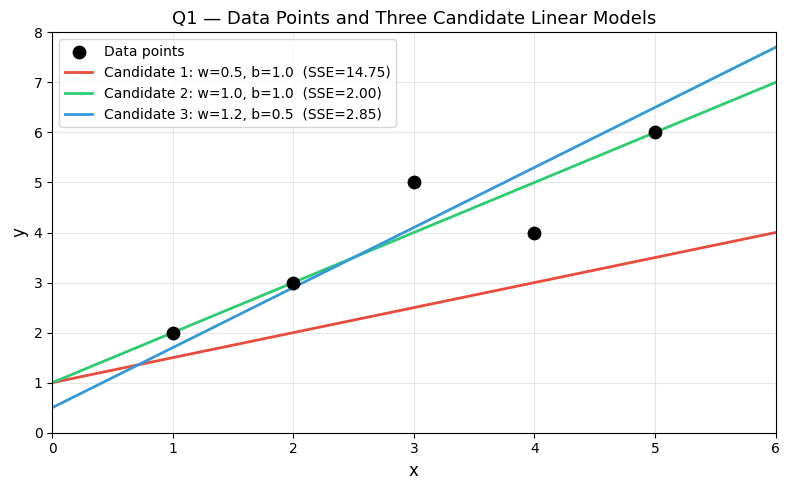

In [38]:
# ── Q1(b)(c): Plot data points and three candidate regression lines ──

# Create a smooth range of x values for drawing continuous lines
x_line = np.linspace(0, 6, 200)       # 200 evenly spaced points from 0 to 6

# Compute the total squared error for each candidate (for the legend labels)
sse_values = []
for w, b in params:
    sse = ((y - (w * x + b)) ** 2).sum()   # SSE for this (w, b) pair
    sse_values.append(sse)

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# (b) Plot the 5 observed data points as black circles
ax.scatter(x, y, color="black", zorder=5, s=80, label="Data points", edgecolors="black")

# (c) Plot each candidate line with its total squared error in the legend
colors = ["#e74c3c", "#2ecc71", "#3498db"]        # Red, green, blue
for idx, ((w, b), sse, color) in enumerate(zip(params, sse_values, colors), start=1):
    y_line = w * x_line + b                        # Predicted y along the smooth x range
    ax.plot(x_line, y_line, color=color, linewidth=2,
            label=f"Candidate {idx}: w={w}, b={b}  (SSE={sse:.2f})")

# Axis labels, title, legend
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.set_title("Q1 — Data Points and Three Candidate Linear Models", fontsize=13)
ax.legend(fontsize=10, loc="upper left")
ax.set_xlim(0, 6)
ax.set_ylim(0, 8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

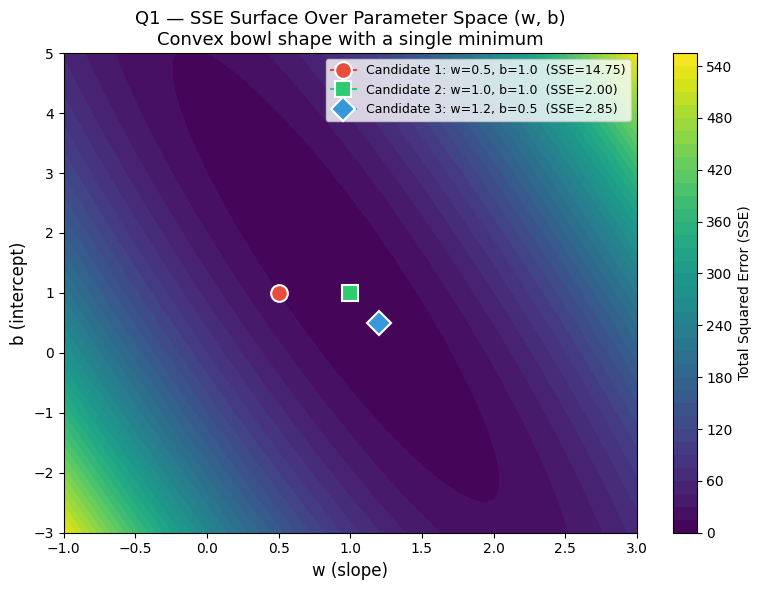

In [39]:
# ── Q1 Supplementary: 3-D SSE Surface over (w, b) to show convexity ──

# Create a grid of (w, b) values to evaluate total squared error across the parameter space
w_grid = np.linspace(-1, 3, 300)           # 300 candidate w values from -1 to 3
b_grid = np.linspace(-3, 5, 300)           # 300 candidate b values from -3 to 5
W, B = np.meshgrid(w_grid, b_grid)         # 2-D mesh so every (w, b) combo is covered

# Compute SSE at every grid point: SSE(w,b) = Σ (y_i - (w*x_i + b))^2
SSE = np.zeros_like(W)                     # Initialise an array of zeros matching grid shape
for xi, yi in zip(x, y):                   # Loop over each data point
    SSE += (yi - (W * xi + B)) ** 2        # Accumulate squared error contribution

# Plot the contour map of the SSE surface
fig, ax = plt.subplots(figsize=(8, 6))
cp = ax.contourf(W, B, SSE, levels=40, cmap="viridis")   # Filled contour with 40 levels
fig.colorbar(cp, ax=ax, label="Total Squared Error (SSE)")

# Mark the three candidate parameter choices on the surface
for idx, ((w_val, b_val), marker, color) in enumerate(
    zip(params, ["o", "s", "D"], ["#e74c3c", "#2ecc71", "#3498db"]), start=1
):
    sse_val = ((y - (w_val * x + b_val)) ** 2).sum()
    ax.plot(w_val, b_val, marker=marker, markersize=12, color=color,
            markeredgecolor="white", markeredgewidth=1.5,
            label=f"Candidate {idx}: w={w_val}, b={b_val}  (SSE={sse_val:.2f})")

ax.set_xlabel("w (slope)", fontsize=12)
ax.set_ylabel("b (intercept)", fontsize=12)
ax.set_title("Q1 — SSE Surface Over Parameter Space (w, b)\nConvex bowl shape with a single minimum",
             fontsize=13)
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

### Part (d) — Analysis and Explanation

**Which line gives the smallest total squared error?**

From the computations in Part (a), Candidate 2 ($w = 1$, $b = 1$) produces the smallest total squared error (SSE = 2.00), followed by Candidate 3 ($w = 1.2$, $b = 0.5$, SSE = 2.85) and Candidate 1 ($w = 0.5$, $b = 1$, SSE = 14.75). The scatter plot in Parts (b)–(c) confirms this visually: the green line (Candidate 2) tracks the overall trend of the data most closely, passing exactly through three of the five data points. The red line (Candidate 1) has a slope that is too shallow and consistently under-predicts the larger $y$ values, resulting in a much larger total error.

**Why least squares can be viewed as an optimization problem.**

Least squares is fundamentally an optimization problem because we are searching for the parameter values $w$ and $b$ that minimize a well-defined objective function — the total squared error, also called the sum of squared residuals. In Lecture 7D, we learned that model fitting involves choosing parameters so that the predicted outputs $\hat{y}_i = wx_i + b$ are as close as possible to the observed outputs $y_i$ (Johns Hopkins University, 2026a). The discrepancy between each prediction and the corresponding observation is measured by the squared difference $(y_i - \hat{y}_i)^2$, and the total squared error $\text{SSE}(w, b) = \sum_{i=1}^{n}(y_i - wx_i - b)^2$ aggregates those discrepancies into a single scalar that we want to make as small as possible. In Lecture 8A, we generalized this viewpoint: any learning task can be framed as choosing parameters $\theta$ to minimize a loss function $L(\theta)$, and gradient-based methods provide a systematic, iterative way to do so (Johns Hopkins University, 2026b). The table computed above demonstrates this concretely — three different parameter settings lead to three different SSE values, and the "best" model is the one at the minimum of that error surface. Optimization gives us the language and the algorithms to navigate that surface efficiently rather than by exhaustive trial and error.

**Why convexity makes the problem easier.**

For a linear model $\hat{y} = wx + b$ with squared-error loss, the objective $\text{SSE}(w, b) = \sum_{i}(y_i - wx_i - b)^2$ is a quadratic function of the parameters $w$ and $b$. A quadratic with a positive semi-definite Hessian is convex by definition, and since the leading term $\sum x_i^2$ is strictly positive for any non-degenerate dataset, the SSE here is strictly convex — meaning the error surface has exactly one global minimum and no other stationary points (Boyd & Vandenberghe, 2004). Geometrically, this strict convexity produces the bowl-shaped contour plot shown above: the SSE surface in $(w, b)$ space consists of concentric, roughly elliptical contours centered on the optimal point, and every downhill direction leads unambiguously toward that unique minimum. In practical terms, convexity guarantees that any local optimum found by an iterative method — such as gradient descent — is also the global optimum. This means there are no plateaus, saddle points, or secondary valleys that could trap an optimizer. If the error surface were non-convex — as it is for neural networks — the optimizer might converge to a local minimum that is far from the true best solution, and the choice of starting point and learning rate would become much more consequential. In summary, because the SSE of a linear model is quadratic and therefore convex, both the theoretical analysis and the practical optimization are simplified: we know in advance that any descent-based procedure will converge to the unique best-fit solution, regardless of initialization (Goodfellow et al., 2016, Chapter 4).

---

## Question 2 — Comparing Optimization Updates (Lecture 8B / 8C)

Consider the one-dimensional objective function:

$$f(w) = (w - 3)^2, \qquad f'(w) = 2(w - 3)$$

Initial parameter value: $w_0 = 0$.

### Part (a) — Basic Gradient Descent

Update rule: $w_{t+1} = w_t - \alpha \, f'(w_t)$, with $\alpha = 0.2$.

In [40]:
# ── Q2(a): Basic Gradient Descent ──

# Define the gradient of f(w) = (w - 3)^2
def f_prime(w):
    """Gradient: f'(w) = 2(w - 3)."""
    return 2 * (w - 3)

alpha = 0.2        # Learning rate
w = 0.0            # Initial parameter value w_0
n_steps = 3        # Number of update steps to compute

# Store history for display and plotting
gd_history = []    # List of (step, w_t, gradient, w_{t+1}) tuples

print("=== Basic Gradient Descent (α = 0.2) ===\n")
print(f"{'Step':>4}  {'w_t':>10}  {'f′(w_t)':>10}  {'w_{t+1}':>10}")
print("-" * 46)

for t in range(n_steps):
    g = f_prime(w)                     # Compute gradient at current w
    w_new = w - alpha * g              # Gradient descent update rule
    gd_history.append((t, w, g, w_new))
    print(f"{t:>4}  {w:>10.4f}  {g:>10.4f}  {w_new:>10.4f}")
    w = w_new                          # Move to the updated parameter value

print(f"\nFinal w after 3 steps: {w:.4f}")

=== Basic Gradient Descent (α = 0.2) ===

Step         w_t     f′(w_t)     w_{t+1}
----------------------------------------------
   0      0.0000     -6.0000      1.2000
   1      1.2000     -3.6000      1.9200
   2      1.9200     -2.1600      2.3520

Final w after 3 steps: 2.3520


### Part (b) — Adaptive-Style Update

Update rule: $w_{t+1} = w_t - \dfrac{\alpha}{\sqrt{g_t^2 + \epsilon}} \, g_t$, with $\alpha = 0.2$, $\epsilon = 10^{-8}$.

In [41]:
# ── Q2(b): Adaptive-Style Update (simplified RMSProp / Adagrad-like) ──

alpha = 0.2            # Learning rate (same as in part a)
epsilon = 1e-8         # Small constant to prevent division by zero
w = 0.0                # Initial parameter value w_0

# Store history for display and plotting
ada_history = []       # List of (step, w_t, gradient, adaptive_lr, w_{t+1}) tuples

print("=== Adaptive-Style Update (α = 0.2, ε = 1e-8) ===\n")
print(f"{'Step':>4}  {'w_t':>10}  {'g_t':>10}  {'α/√(g²+ε)':>12}  {'Δw':>10}  {'w_{t+1}':>10}")
print("-" * 66)

for t in range(n_steps):
    g = f_prime(w)                                # Gradient at current w
    adaptive_lr = alpha / np.sqrt(g ** 2 + epsilon)  # Effective learning rate
    delta_w = adaptive_lr * g                     # Magnitude of the update
    w_new = w - delta_w                           # Adaptive update rule
    ada_history.append((t, w, g, adaptive_lr, w_new))
    print(f"{t:>4}  {w:>10.4f}  {g:>10.4f}  {adaptive_lr:>12.6f}  {delta_w:>10.4f}  {w_new:>10.4f}")
    w = w_new                                     # Advance to updated value

print(f"\nFinal w after 3 steps: {w:.4f}")

=== Adaptive-Style Update (α = 0.2, ε = 1e-8) ===

Step         w_t         g_t     α/√(g²+ε)          Δw     w_{t+1}
------------------------------------------------------------------
   0      0.0000     -6.0000      0.033333     -0.2000      0.2000
   1      0.2000     -5.6000      0.035714     -0.2000      0.4000
   2      0.4000     -5.2000      0.038462     -0.2000      0.6000

Final w after 3 steps: 0.6000


### Visual Comparison — Gradient Descent vs. Adaptive Update on $f(w) = (w-3)^2$

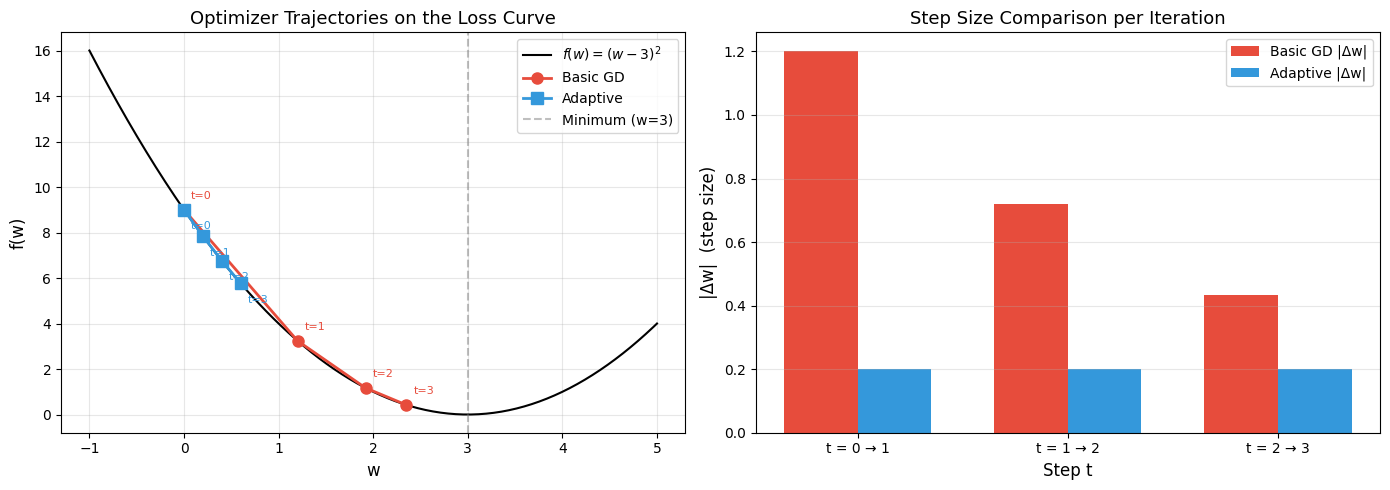

In [42]:
# ── Q2 Visualization: Compare both optimizers on the loss curve ──

# Objective function values for plotting the parabola
w_range = np.linspace(-1, 5, 300)             # Domain of w for the curve
f_vals = (w_range - 3) ** 2                   # f(w) = (w - 3)^2

# Extract w trajectories from recorded histories
gd_w = [h[1] for h in gd_history] + [gd_history[-1][3]]     # w_0, w_1, w_2, w_3
ada_w = [h[1] for h in ada_history] + [ada_history[-1][4]]   # w_0, w_1, w_2, w_3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left panel: both trajectories on the loss curve ──
ax = axes[0]
ax.plot(w_range, f_vals, "k-", linewidth=1.5, label=r"$f(w) = (w-3)^2$")
ax.plot(gd_w, [(wi - 3)**2 for wi in gd_w], "o-", color="#e74c3c",
        markersize=8, linewidth=2, label="Basic GD")
ax.plot(ada_w, [(wi - 3)**2 for wi in ada_w], "s-", color="#3498db",
        markersize=8, linewidth=2, label="Adaptive")
# Annotate each step
for i, (gw, aw) in enumerate(zip(gd_w, ada_w)):
    ax.annotate(f"t={i}", (gw, (gw-3)**2), textcoords="offset points",
                xytext=(5, 8), fontsize=8, color="#e74c3c")
    ax.annotate(f"t={i}", (aw, (aw-3)**2), textcoords="offset points",
                xytext=(5, -14), fontsize=8, color="#3498db")
ax.axvline(3, color="gray", linestyle="--", alpha=0.5, label="Minimum (w=3)")
ax.set_xlabel("w", fontsize=12)
ax.set_ylabel("f(w)", fontsize=12)
ax.set_title("Optimizer Trajectories on the Loss Curve", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── Right panel: step size (|Δw|) at each iteration ──
ax2 = axes[1]
gd_steps = [abs(gd_history[i][3] - gd_history[i][1]) for i in range(3)]
ada_steps = [abs(ada_history[i][4] - ada_history[i][1]) for i in range(3)]
bar_x = np.arange(3)
width = 0.35
ax2.bar(bar_x - width/2, gd_steps, width, color="#e74c3c", label="Basic GD |Δw|")
ax2.bar(bar_x + width/2, ada_steps, width, color="#3498db", label="Adaptive |Δw|")
ax2.set_xlabel("Step t", fontsize=12)
ax2.set_ylabel("|Δw|  (step size)", fontsize=12)
ax2.set_title("Step Size Comparison per Iteration", fontsize=13)
ax2.set_xticks(bar_x)
ax2.set_xticklabels(["t = 0 → 1", "t = 1 → 2", "t = 2 → 3"])
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

### Part (c) — Comparison of Behaviors

**Which method changes $w$ by a larger amount?**

Basic gradient descent produces larger absolute step sizes in this example. At the first iteration the gradient is $f'(0) = -6$, so the basic GD step is $\Delta w = \alpha \cdot |g| = 0.2 \times 6 = 1.2$. In contrast, the adaptive rule divides by $\sqrt{g^2 + \epsilon} \approx |g|$, so the effective step is $\alpha \cdot |g| / |g| = \alpha = 0.2$ regardless of gradient magnitude. As the parameter approaches the minimum and the gradient shrinks, basic GD step sizes shrink proportionally (0.72 at step 2, 0.432 at step 3), whereas the adaptive method continues to take steps of approximately 0.2 at every iteration. Therefore, in the early phase — when $w$ is far from the minimum and the gradient is large — basic gradient descent moves $w$ by a substantially larger amount per step.

**Which method is less sensitive to gradient magnitude?**

The adaptive-style update is designed to be far less sensitive to the magnitude of the gradient. By dividing the gradient $g_t$ by its own absolute value $\sqrt{g_t^2 + \epsilon}$, the rule effectively normalizes the update so that the step size is close to $\alpha$ at every iteration, independent of how steep or flat the loss surface happens to be at the current location. This is precisely the design philosophy behind adaptive optimizers such as Adagrad, RMSProp, and Adam, which were discussed in Lecture 8C (Johns Hopkins University, 2026c). The small constant $\epsilon$ prevents division by zero when the gradient is near zero, but otherwise the normalization dominates. In basic gradient descent, by contrast, the step size is directly proportional to the gradient: large gradients produce large jumps, and small gradients produce tiny, potentially sluggish, movements.

**What does this suggest about optimizer choice during training?**

This comparison illustrates a key insight from Lectures 8B and 8C: different optimizers navigate the same loss surface in fundamentally different ways, and the choice of optimizer can significantly affect both the speed and stability of training (Johns Hopkins University, 2026c). Basic gradient descent is simple and effective when the loss surface is well-conditioned — that is, when the gradient magnitude provides a reliable signal for how far to move. However, on complex surfaces where the gradient can vary by orders of magnitude across different regions or different parameters, a fixed learning rate can cause oscillation in steep directions and slow progress in flat directions. Adaptive methods address this by automatically rescaling each parameter's update, allowing faster convergence on ill-conditioned surfaces that frequently arise in deep learning. The bar chart above shows this effect concretely: the adaptive method maintains a nearly uniform step size regardless of how the gradient changes, while basic GD's step size decays sharply as the optimizer approaches the minimum. In practice, this means adaptive methods like Adam often converge more quickly in the early phase of training and are more robust to the choice of learning rate (Kingma & Ba, 2015). However, basic GD (and its momentum-based variants) can sometimes find better final solutions because the gradient-proportional steps let the optimizer slow down naturally near the minimum, whereas adaptive methods may overshoot in the final stages (Goodfellow et al., 2016, Chapter 8).

---

## Question 3 — Reasoning About Learning Behavior (Lecture 8D)

Consider two models:

| | Model 1 — Logistic Regression | Model 2 — Small Neural Network |
|---|---|---|
| **Architecture** | $\hat{y} = \sigma(w^T x + b)$ | $h = \text{ReLU}(W_1 x + b_1), \; \hat{y} = \sigma(W_2 h + b_2)$ |
| **Loss** | Binary cross-entropy (+ optional L2) | Binary cross-entropy |
| **Training** | Gradient descent | Gradient descent with backpropagation |

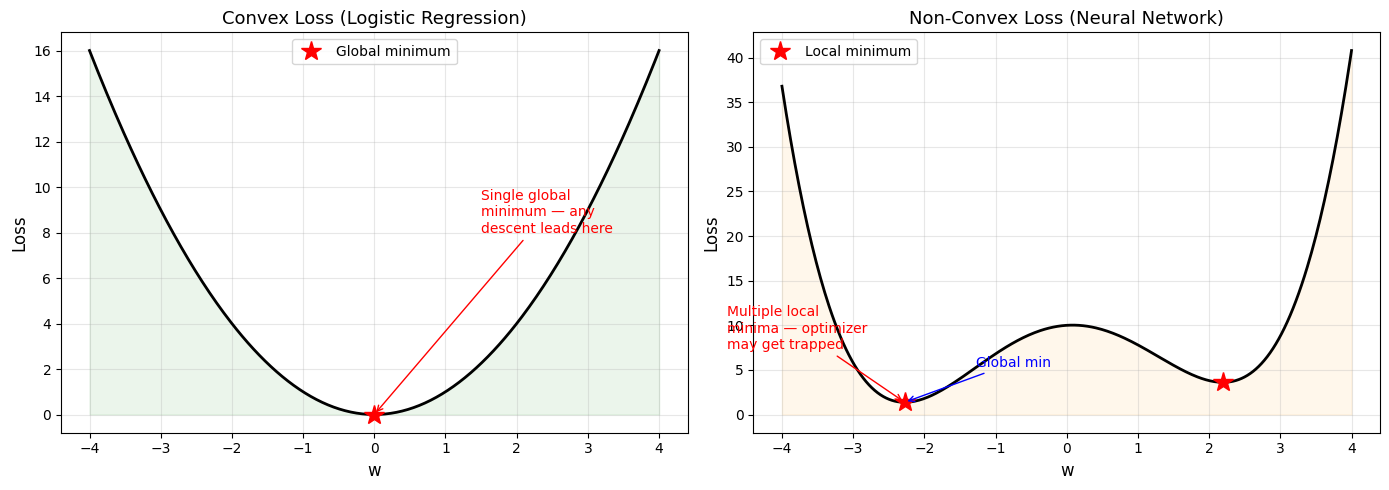

In [43]:
# ── Q3 Illustration: Convex vs Non-Convex Loss Surfaces ──
# This visualization supports the conceptual answers below by showing
# why logistic regression (convex) is easier to optimize than a neural network (non-convex).

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Convex loss surface (logistic regression analogy) ──
w_vals = np.linspace(-4, 4, 400)
convex_loss = w_vals ** 2                           # Simple convex (bowl-shaped) loss
ax = axes[0]
ax.plot(w_vals, convex_loss, "k-", linewidth=2)
ax.fill_between(w_vals, convex_loss, alpha=0.08, color="green")
ax.plot(0, 0, "r*", markersize=15, label="Global minimum")
ax.set_title("Convex Loss (Logistic Regression)", fontsize=13)
ax.set_xlabel("w", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.annotate("Single global\nminimum — any\ndescent leads here",
            xy=(0, 0), xytext=(1.5, 8), fontsize=10,
            arrowprops=dict(arrowstyle="->", color="red"), color="red")

# ── Right: Non-convex loss surface (neural network analogy) ──
non_convex_loss = (0.3 * w_vals ** 4 - 3 * w_vals ** 2 + 0.5 * w_vals + 10)
ax2 = axes[1]
ax2.plot(w_vals, non_convex_loss, "k-", linewidth=2)
ax2.fill_between(w_vals, non_convex_loss, alpha=0.08, color="orange")

# Find and mark local minima using simple numpy comparison (no scipy needed)
# A point is a local minimum if it is lower than both its neighbors
is_local_min = np.zeros(len(non_convex_loss), dtype=bool)
for i in range(1, len(non_convex_loss) - 1):
    if non_convex_loss[i] < non_convex_loss[i-1] and non_convex_loss[i] < non_convex_loss[i+1]:
        is_local_min[i] = True
# Thin out nearby minima: keep only one per valley (spaced at least 20 indices apart)
local_min_idx = np.where(is_local_min)[0]
filtered = [local_min_idx[0]]
for idx in local_min_idx[1:]:
    if idx - filtered[-1] > 20:
        filtered.append(idx)
local_min_idx = np.array(filtered)
for i, idx in enumerate(local_min_idx):
    label = "Local minimum" if i == 0 else None
    ax2.plot(w_vals[idx], non_convex_loss[idx], "r*", markersize=15, label=label)
global_min_idx = local_min_idx[np.argmin(non_convex_loss[local_min_idx])]
ax2.annotate("Global min", xy=(w_vals[global_min_idx], non_convex_loss[global_min_idx]),
             xytext=(w_vals[global_min_idx] + 1, non_convex_loss[global_min_idx] + 4),
             fontsize=10, arrowprops=dict(arrowstyle="->", color="blue"), color="blue")
ax2.set_title("Non-Convex Loss (Neural Network)", fontsize=13)
ax2.set_xlabel("w", fontsize=12)
ax2.set_ylabel("Loss", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.annotate("Multiple local\nminima — optimizer\nmay get trapped",
             xy=(w_vals[local_min_idx[0]], non_convex_loss[local_min_idx[0]]),
             xytext=(w_vals[local_min_idx[0]] - 2.5, non_convex_loss[local_min_idx[0]] + 6),
             fontsize=10, arrowprops=dict(arrowstyle="->", color="red"), color="red")

plt.tight_layout()
plt.show()

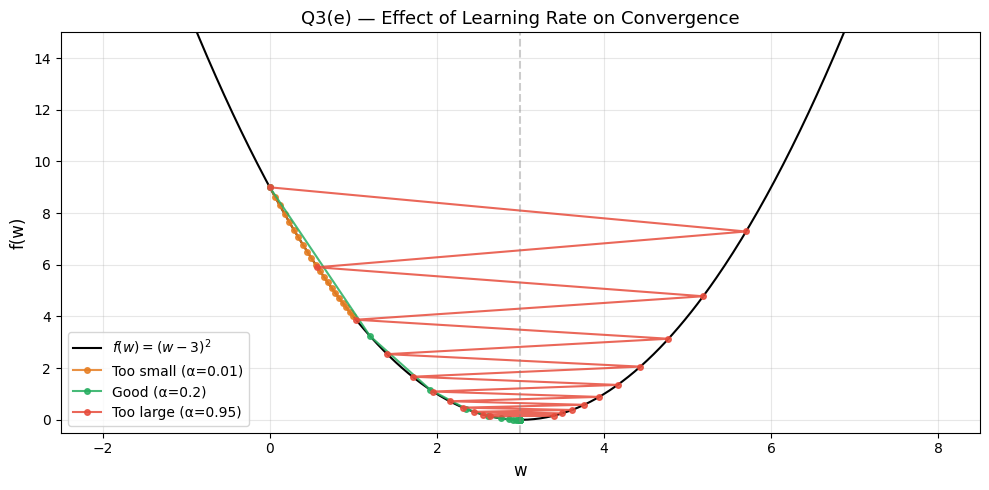

In [44]:
# ── Q3(e) Illustration: Effect of Learning Rate on Training Trajectory ──

def f(w):
    """Objective function f(w) = (w-3)^2."""
    return (w - 3) ** 2

w_range = np.linspace(-2, 8, 400)
f_range = f(w_range)

# Simulate gradient descent for three learning rates
learning_rates = {"Too small (α=0.01)": 0.01,
                  "Good (α=0.2)": 0.2,
                  "Too large (α=0.95)": 0.95}
colors_lr = {"Too small (α=0.01)": "#e67e22",
             "Good (α=0.2)": "#27ae60",
             "Too large (α=0.95)": "#e74c3c"}
n_iter = 20

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(w_range, f_range, "k-", linewidth=1.5, label=r"$f(w) = (w-3)^2$")

for name, lr in learning_rates.items():
    w = 0.0
    trajectory = [w]
    for _ in range(n_iter):
        g = 2 * (w - 3)              # Gradient
        w = w - lr * g               # Update
        trajectory.append(w)
    trajectory = np.array(trajectory)
    ax.plot(trajectory, f(trajectory), "o-", color=colors_lr[name],
            markersize=4, linewidth=1.5, label=name, alpha=0.85)

ax.axvline(3, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("w", fontsize=12)
ax.set_ylabel("f(w)", fontsize=12)
ax.set_title("Q3(e) — Effect of Learning Rate on Convergence", fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(-0.5, 15)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Answers to Parts (a)–(f)

#### (a) Convex vs. Non-Convex

Logistic regression leads to a **convex** optimization problem — and, under typical conditions, a **strictly convex** one. The binary cross-entropy loss, when composed with the linear function $w^T x + b$ passed through the sigmoid $\sigma$, produces a loss surface that is convex in the parameters $w$ and $b$. Its Hessian takes the form $H = X^T D X$, where $D$ is a diagonal matrix whose entries $\sigma(z_i)(1 - \sigma(z_i))$ are strictly positive on any finite dataset. When the design matrix $X$ has full column rank, $H$ is positive definite (not merely positive semi-definite), which guarantees strict convexity and a unique global minimum (Bishop, 2006, Section 4.3.3). By contrast, the small neural network with a hidden layer and ReLU activation produces a **non-convex** optimization problem. The composition of two linear transformations with a nonlinear activation (ReLU) and a final sigmoid introduces interactions between the weight matrices $W_1$ and $W_2$ that create multiple local minima, saddle points, and flat regions in the loss surface (Goodfellow et al., 2016, Chapter 8). The left and right panels of the chart above illustrate these two cases schematically: the convex surface has a single, well-defined bowl, while the non-convex surface has multiple valleys where an optimizer might settle.

#### (b) Why Optimization Is Easier for Logistic Regression

Optimization is generally easier for logistic regression because its convex loss surface guarantees that any local minimum is also the global minimum. A gradient descent procedure starting from any initial point will descend monotonically toward the unique optimum, provided the learning rate is chosen appropriately (Boyd & Vandenberghe, 2004). For the neural network, the non-convex surface contains many local minima and saddle points. The optimizer's trajectory depends heavily on the initialization of the weight matrices, the learning rate schedule, and the choice of optimizer. Two training runs with different random seeds may converge to different solutions with different loss values. Additionally, the neural network has more parameters — the weight matrix $W_1$, biases $b_1$, output weights $W_2$, and bias $b_2$ — increasing the dimensionality of the search space and the computational cost per gradient evaluation.

#### (c) Why the Neural Network Requires Backpropagation

In logistic regression, the gradient of the loss with respect to $w$ and $b$ can be written in a single closed-form expression because there is only one layer of computation. In the neural network, the output $\hat{y}$ depends on $W_2$ and $b_2$ directly, but it depends on $W_1$ and $b_1$ only indirectly through the hidden representation $h = \text{ReLU}(W_1 x + b_1)$. To compute how the loss changes with respect to the first-layer weights, we must apply the chain rule of calculus layer by layer — propagating the error signal backward from the output through $W_2$, through the ReLU nonlinearity, and finally to $W_1$. This systematic, recursive application of the chain rule is called backpropagation (Rumelhart et al., 1986). Without it, computing the gradient with respect to earlier layers would require enumerating every possible path through the network, which is computationally infeasible for anything beyond the simplest architectures. As noted in Lecture 8D, backpropagation is not a separate learning algorithm; it is simply an efficient method for evaluating the gradient of a composite function (Johns Hopkins University, 2026d).

#### (d) Role of Regularization

Regularization adds a penalty term to the loss function — for example, L2 regularization adds $\frac{\lambda}{2} \|w\|^2$ — that discourages the model from assigning excessively large values to any parameter. In gradient-based learning, this penalty modifies the gradient by adding a term proportional to the weight itself ($\lambda w$), effectively pulling all weights toward zero at every update step. The practical effect is to reduce overfitting: a model with smaller weights produces smoother decision boundaries that generalize better to unseen data. For logistic regression, the unregularized binary cross-entropy loss is already strictly convex when the design matrix has full column rank, because its Hessian $X^T D X$ (where $D$ is a diagonal matrix of positive sigmoid-derived terms) is positive definite under that condition (Bishop, 2006, Section 4.3.3). Adding L2 regularization further strengthens convexity by contributing an additive $\lambda I$ term to the Hessian, which is especially beneficial when the features are nearly collinear and the unregularized Hessian is close to singular — in such edge cases the regularizer ensures the problem remains well-conditioned and the solution unique. For neural networks, regularization helps navigate the non-convex surface by penalizing excessively complex solutions that correspond to sharp, narrow minima, thereby encouraging convergence to flatter minima that tend to generalize better (Goodfellow et al., 2016, Chapter 7).

#### (e) Effect of Learning Rate

The chart above ("Effect of Learning Rate on Convergence") demonstrates three regimes. When the learning rate is **too small** ($\alpha = 0.01$), the optimizer takes tiny steps and converges extremely slowly; after 20 iterations it has barely moved toward the minimum. Training in this regime wastes computation and may appear to stall. When the learning rate is **too large** ($\alpha = 0.95$), the optimizer overshoots the minimum on every step, causing the trajectory to oscillate back and forth across the valley. In extreme cases the oscillations grow and the loss diverges to infinity, meaning the model fails to learn entirely. A **well-chosen** learning rate ($\alpha = 0.2$) balances speed and stability: the optimizer descends rapidly at first, then naturally slows as the gradient shrinks near the minimum, reaching a good solution in relatively few iterations. This trade-off is one of the central practical challenges in training any gradient-based model and motivates the use of adaptive learning rate methods and learning-rate schedules (Johns Hopkins University, 2026b; Kingma & Ba, 2015).

#### (f) "Learning is an optimization process, but the challenge depends on model structure."

Learning can be understood as the process of iteratively adjusting model parameters to minimize a loss function that quantifies prediction error. For a simple model like logistic regression, the loss surface is convex, so gradient descent is guaranteed to find the single best solution regardless of where it starts, and the optimization is straightforward. For a more complex model like a neural network with hidden layers and nonlinear activations, the loss surface becomes non-convex with many local minima, saddle points, and flat plateaus. In this setting, the choice of optimizer, learning rate, initialization, and regularization all become critical design decisions because they determine which region of the parameter space the model ultimately converges to. Therefore, while the goal — minimizing loss — is the same in both cases, the difficulty of actually achieving that goal scales with the depth and nonlinearity of the model architecture (Johns Hopkins University, 2026d; Goodfellow et al., 2016, Chapter 8).

---

## References

Bishop, C. M. (2006). *Pattern recognition and machine learning*. Springer. https://www.springer.com/gp/book/9780387310732

Boyd, S., & Vandenberghe, L. (2004). *Convex optimization*. Cambridge University Press. https://web.stanford.edu/~boyd/cvxbook/

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press. https://www.deeplearningbook.org/

Johns Hopkins University. (2026a). *Module 7 – Lecture 7D: Least squares and conditioning* [Lecture slides]. EN.705.623 AI Algorithm Design and Analysis, Spring 2026.

Johns Hopkins University. (2026b). *Module 8 – Lecture 8A: Optimization as a learning problem* [Lecture slides]. EN.705.623 AI Algorithm Design and Analysis, Spring 2026.

Johns Hopkins University. (2026c). *Module 8 – Lecture 8C: Adaptive optimizers* [Lecture slides]. EN.705.623 AI Algorithm Design and Analysis, Spring 2026.

Johns Hopkins University. (2026d). *Module 8 – Lecture 8D: From logistic regression to neural networks* [Lecture slides]. EN.705.623 AI Algorithm Design and Analysis, Spring 2026.

Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. In *Proceedings of the 3rd International Conference on Learning Representations (ICLR 2015)*. https://arxiv.org/abs/1412.6980

Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. *Nature*, *323*(6088), 533–536. https://doi.org/10.1038/323533a0